In [4]:
df = pd.read_excel(file_path)
df.to_csv("online_retail.csv", index=False)

In [5]:
import pandas as pd

# Display all columns
pd.set_option('display.max_columns', None)

# Load dataset
file_path = "online_retail.csv"
df = pd.read_csv(file_path)

# Show first 5 rows
print("First 5 rows:")
display(df.head())

# Shape of dataset
print("\nDataset Shape:")
print(df.shape)

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Dataset Shape:
(541909, 8)

Data Types:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


## Step 1 Insights

### Dataset Overview
- The dataset contains **541,909 rows** and **8 columns**, indicating a large transactional dataset suitable for analysis.
- Each row represents a single product within an invoice.

### Data Types Observations
- `InvoiceDate` is currently stored as **object**, not datetime → needs conversion.
- `CustomerID` is stored as **float**, which is not ideal for IDs.
- Categorical columns: InvoiceNo, StockCode, Description, Country.

### Missing Values
- `CustomerID` has **135,080 missing values (~25%)**
  → This is significant and will affect customer-level analysis.
- `Description` has **1,454 missing values**
  → Relatively small and can be handled easily.

### Initial Observations
- Dataset is well-structured with clear transactional fields.
- Suitable for:
  - Sales analysis
  - Customer segmentation
  - Time-based analysis
- Requires data cleaning before proceeding to EDA.

### Potential Issues to Address
- Missing Customer IDs
- Incorrect data type for InvoiceDate
- Possible returns (negative quantities) — to be checked later

# Step 2: Data Cleaning

In this step, we will clean and prepare the dataset for analysis.

Steps:
1. Convert InvoiceDate to datetime format
2. Remove rows with missing CustomerID (for customer analysis)
3. Remove rows with missing Description
4. Remove negative or zero Quantity (returns or invalid data)
5. Remove zero or negative UnitPrice
6. Remove duplicates

Goal:
Ensure clean and reliable data before performing EDA and machine learning.

In [6]:
# Create a copy for cleaning
df_clean = df.copy()

# 1. Convert InvoiceDate to datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# 2. Remove missing CustomerID (for customer-based analysis)
df_clean = df_clean.dropna(subset=['CustomerID'])

# 3. Remove missing Description
df_clean = df_clean.dropna(subset=['Description'])

# 4. Remove negative or zero Quantity
df_clean = df_clean[df_clean['Quantity'] > 0]

# 5. Remove zero or negative UnitPrice
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# 6. Remove duplicates
df_clean = df_clean.drop_duplicates()

# Check new shape
print("Cleaned Dataset Shape:")
print(df_clean.shape)

Cleaned Dataset Shape:
(392692, 8)


## Step 2 Insights

### Data Reduction
- The dataset was reduced from **541,909 rows** to **392,692 rows** after cleaning.
- Approximately **27% of the data was removed** during cleaning.

### Reasons for Data Removal
- Missing Customer IDs (required for customer-level analysis)
- Missing product descriptions
- Invalid transactions:
  - Negative or zero quantities (returns or errors)
  - Zero or negative prices
- Duplicate records

### Key Observations
- A significant portion of transactions did not have Customer IDs, indicating guest or unregistered purchases.
- Removing negative quantities ensures we are analyzing only valid sales (excluding returns).

### Data Quality Improvement
- The dataset is now:
  - Consistent
  - Reliable
  - Ready for customer segmentation and machine learning

### Important Note
- This cleaned dataset (`df_clean`) will be used for:
  - Customer segmentation (RFM)
  - Machine Learning models

- The original dataset (`df`) will still be used for:
  - Sales analysis (EDA)

# Step 3: Feature Engineering

In this step, we will create new features to enhance analysis and modeling.

Steps:
1. Create TotalPrice column (Quantity × UnitPrice)
2. Extract time-based features from InvoiceDate:
   - Year
   - Month
   - Day
   - Hour
3. Prepare the dataset for deeper analysis

Goal:
Transform raw data into meaningful features for EDA and machine learning.

In [7]:
# Create TotalPrice
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Extract date features
df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['Day'] = df_clean['InvoiceDate'].dt.day
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

# Quick check
print(df_clean.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  \
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom       15.30   
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34   
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom       22.00   
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34   
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34   

   Year  Month  Day  Hour  
0  2010     12    1     8  
1  2010     12    1     8  
2  2010     12    1     8 

## Step 3 Insights

### Feature Creation
- A new column `TotalPrice` was successfully created:
  - Represents the total value of each transaction (Quantity × UnitPrice)
  - This will be the key metric for revenue analysis and customer value

### Time-Based Features
- Extracted features:
  - `Year`, `Month`, `Day`, `Hour`
- These features will enable:
  - Time series analysis
  - Identifying sales patterns (peak hours, peak months)

### Key Observations
- The dataset now contains both transactional and temporal information.
- Each record now provides:
  - What was purchased
  - When it was purchased
  - How much revenue it generated

### Data Readiness
- The dataset is now fully prepared for:
  - Exploratory Data Analysis (EDA)
  - Customer segmentation (RFM)
  - Machine learning models

### Important Note
- `TotalPrice` will be used as the main metric for:
  - Revenue calculation
  - Customer monetary value (RFM)

# Step 4: General Overview & Revenue Analysis

In this step, we will explore the overall dataset and key business metrics.

Steps:
1. Calculate total revenue
2. Count number of unique invoices
3. Count number of unique customers
4. Count number of unique products
5. Identify top-selling products

Goal:
Understand the overall business performance and key metrics.

In [8]:
# Total Revenue
total_revenue = df_clean['TotalPrice'].sum()
print("Total Revenue:", total_revenue)

# Number of invoices
num_invoices = df_clean['InvoiceNo'].nunique()
print("Number of Invoices:", num_invoices)

# Number of customers
num_customers = df_clean['CustomerID'].nunique()
print("Number of Customers:", num_customers)

# Number of products
num_products = df_clean['StockCode'].nunique()
print("Number of Products:", num_products)

# Top 10 products by quantity
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Products by Quantity:")
print(top_products)

Total Revenue: 8887208.894
Number of Invoices: 18532
Number of Customers: 4338
Number of Products: 3665

Top 10 Products by Quantity:
Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


## Step 4 Insights

### Business Overview
- The total revenue generated is approximately **8.89 million**, indicating strong overall sales performance.
- The dataset includes **18,532 unique invoices**, representing total transactions.
- There are **4,338 unique customers**, showing a solid customer base.
- The company sells **3,665 unique products**, indicating a diverse product catalog.

### Customer Behavior
- The number of customers is significantly lower than invoices:
  - This suggests that customers make multiple purchases (repeat behavior).
- Average orders per customer ≈ 4.27 orders
  → Indicates good customer retention.

### Product Insights
- Some products are sold in extremely high volumes:
  - "PAPER CRAFT, LITTLE BIRDIE" → ~80K units
  - "MEDIUM CERAMIC TOP STORAGE JAR" → ~77K units
- These are likely:
  - Best-selling products
  - Potential "core revenue drivers"

### Business Implications
- High-volume products should be:
  - Prioritized in inventory
  - Highlighted in marketing campaigns

- Customer retention seems strong:
  - Opportunity to build loyalty programs

### Key Insight
- The business relies on a mix of:
  - High-frequency customers
  - High-volume products

# Step 5: Top Products Visualization

In this step, we will visualize the top-selling products based on quantity.

Goal:
Identify the most popular products visually.

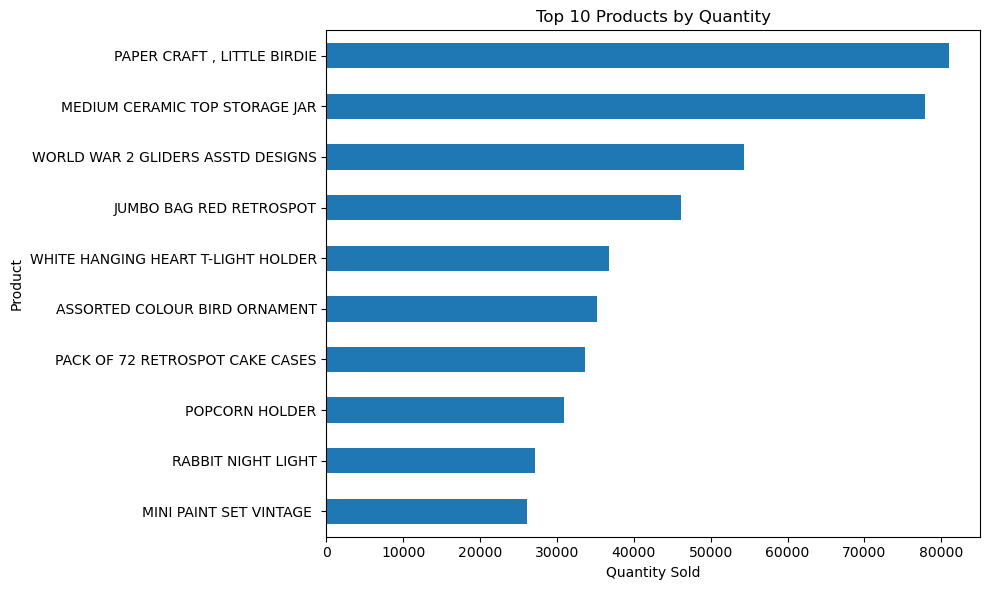

In [11]:
import matplotlib.pyplot as plt

# Top 10 products
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=True).tail(10)

# Plot (horizontal)
plt.figure(figsize=(10,6))
top_products.plot(kind='barh')

plt.title("Top 10 Products by Quantity")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

## Step 5 Insights

### Product Performance
- A small group of products dominates total sales volume.
- "PAPER CRAFT, LITTLE BIRDIE" is the top-selling product with a significant margin.

### Key Observation
- The top 2 products significantly outperform the rest:
  - Indicates strong demand concentration
  - Suggests a "Pareto effect" (few products drive most sales)

### Product Strategy Insights
- Best-selling products should be:
  - Always in stock
  - Promoted in marketing campaigns
  - Bundled with other products for upselling

### Business Opportunity
- Products with similar characteristics to top sellers can be:
  - Recommended to customers
  - Used in cross-selling strategies

### Risk Insight
- Heavy reliance on a few products may create risk:
  - If supply issues occur → revenue impact

### Key Takeaway
- The business is driven by a limited number of high-performing products.

# Step 6: Monthly Sales Analysis

In this step, we analyze how sales change over time.

Steps:
1. Group data by month
2. Calculate total revenue per month
3. Visualize monthly sales

Goal:
Identify trends, seasonality, and peak sales periods.

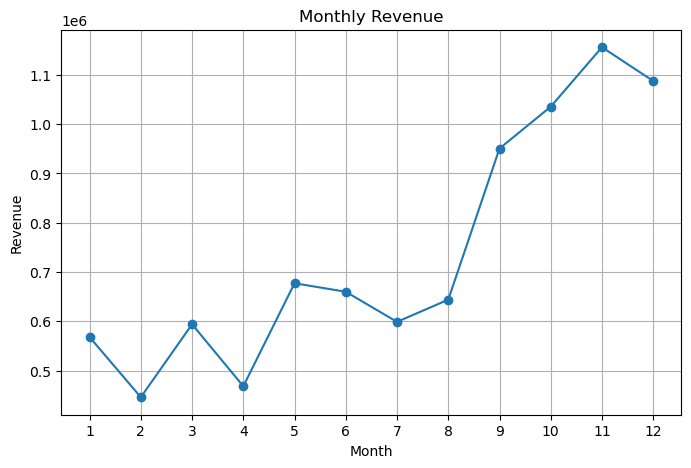

In [12]:
# Monthly revenue
monthly_sales = df_clean.groupby('Month')['TotalPrice'].sum()

# Plot
plt.figure(figsize=(8,5))
monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(range(1,13))
plt.grid()

plt.show()

## Step 6 Insights

### Sales Trend Over Time
- Revenue shows a clear upward trend throughout the year.
- Sales start relatively low in early months (Jan–Apr) and gradually increase.

### Peak Sales Period
- The highest revenue occurs in **November**, followed by **December**.
- This indicates strong seasonal demand at the end of the year.

### Seasonality Insight
- There is a noticeable spike starting from **September → December**.
- This suggests:
  - Holiday season impact
  - Increased customer spending (e.g., Christmas period)

### Low Performance Period
- February shows the lowest revenue.
- Early months (Q1) generally have weaker sales performance.

### Business Implications
- Inventory planning:
  - Stock should be increased before Q4 (Sep–Dec)
- Marketing:
  - Campaigns should be intensified before peak months
- Discounts:
  - Can be used in low months (Jan–Feb) to boost sales

### Key Takeaway
- The business is highly seasonal, with peak performance in Q4.

# Step 7: Hourly Sales Analysis

In this step, we analyze sales distribution across different hours of the day.

Steps:
1. Group data by hour
2. Calculate total revenue per hour
3. Visualize hourly sales

Goal:
Identify peak shopping hours during the day.

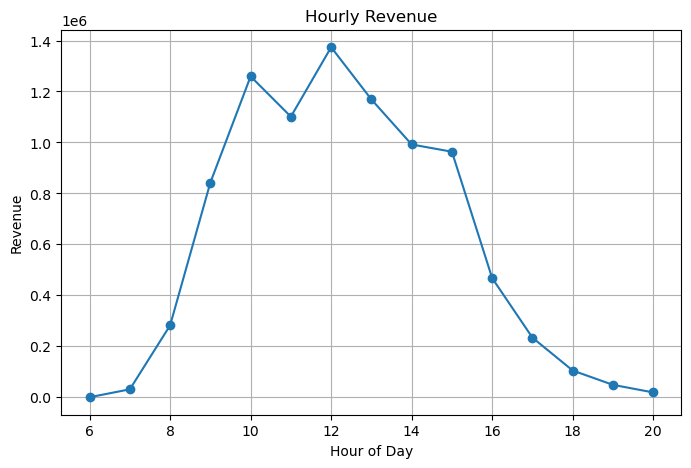

In [13]:
# Hourly revenue
hourly_sales = df_clean.groupby('Hour')['TotalPrice'].sum()

# Plot
plt.figure(figsize=(8,5))
hourly_sales.plot(kind='line', marker='o')

plt.title("Hourly Revenue")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue")

plt.grid()
plt.show()

## Step 7 Insights

### Peak Shopping Hours
- The highest revenue occurs around **12 PM (noon)**.
- Strong activity is also observed between **10 AM and 2 PM**.

### Customer Behavior
- Customers are most active خلال:
  - Late morning → early afternoon
- This suggests:
  - Many purchases happen during working hours
  - Possibly B2B or office-related buying behavior

### Low Activity Period
- Very low sales early morning (6–8 AM) and evening (after 5 PM).
- Indicates that customers are less active outside business hours.

### Sales Pattern
- Revenue increases steadily from morning (8 AM)
- Peaks at midday
- ثم يبدأ يقل تدريجيًا بعد كده

### Business Implications
- Marketing campaigns:
  - Best timing → **10 AM – 2 PM**
- Promotions:
  - ممكن تتعمل في ساعات الضعف (evening) لزيادة المبيعات
- Operations:
  - Ensure system stability during peak hours

### Key Takeaway
- The business follows a **daytime purchasing pattern**, with peak activity around noon.

# Step 8: Country Analysis

In this step, we analyze revenue by country.

Steps:
1. Group data by country
2. Calculate total revenue per country
3. Visualize top countries

Goal:
Identify the most valuable markets.

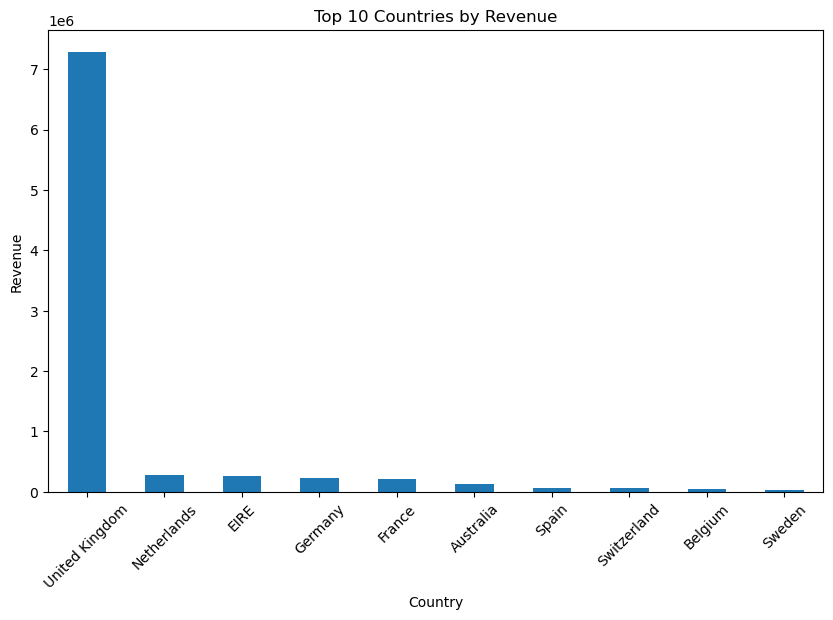

In [14]:
# Revenue by country
country_sales = df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10,6))
country_sales.plot(kind='bar')

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.show()

## Step 8 Insights

### Market Dominance
- The **United Kingdom overwhelmingly dominates revenue**.
- It generates the vast majority of total sales compared to all other countries.

### Key Observation
- There is a huge gap between the UK and the rest of the countries.
- Other countries contribute only a small fraction of total revenue.

### Top International Markets
- After the UK, the top contributing countries include:
  - Netherlands
  - EIRE (Ireland)
  - Germany
  - France

### Business Implications
- The business is heavily dependent on a single market (UK):
  - High stability if UK demand is strong
  - High risk if UK market declines

### Growth Opportunities
- International markets are underdeveloped:
  - Potential to expand marketing in Europe
  - Opportunity to grow revenue outside UK

### Strategic Insight
- Focus areas:
  - Maintain dominance in UK
  - Expand in top secondary markets (Netherlands, Germany, France)

### Key Takeaway
- The company has a **strong local market dominance** but significant opportunity for global expansion.

# Step 9: Top Customers Analysis

In this step, we analyze the most valuable customers.

Steps:
1. Group data by CustomerID
2. Calculate total spending per customer
3. Identify top customers
4. Visualize top customers

Goal:
Identify high-value customers for business targeting.

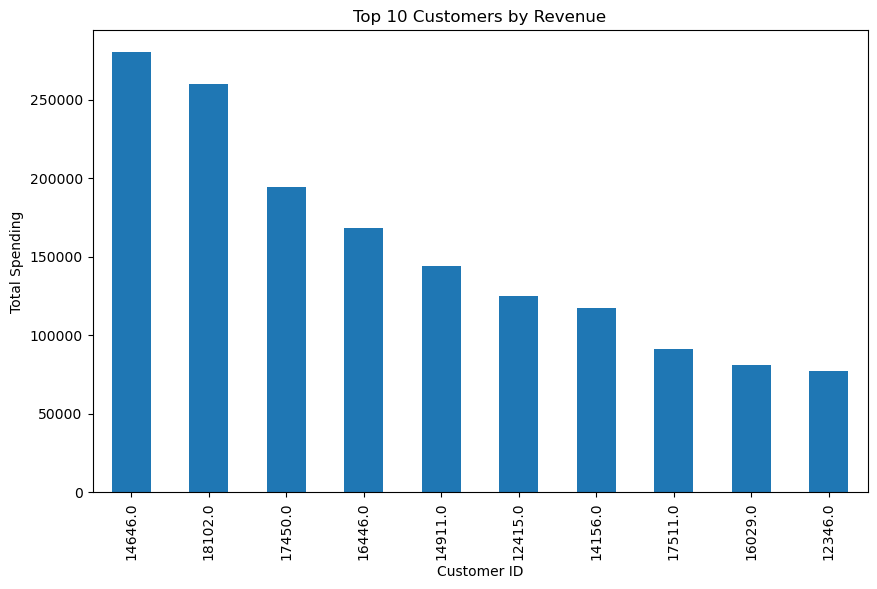

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: TotalPrice, dtype: float64


In [15]:
# Top customers by revenue
top_customers = df_clean.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10,6))
top_customers.plot(kind='bar')

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Total Spending")

plt.show()

# Print values
print(top_customers)

# Extra Step: Top 3 Products by Revenue (Pie Chart)

In this step, we visualize the top 3 products by revenue using a pie chart.

Goal:
Highlight the contribution of top products to total revenue.

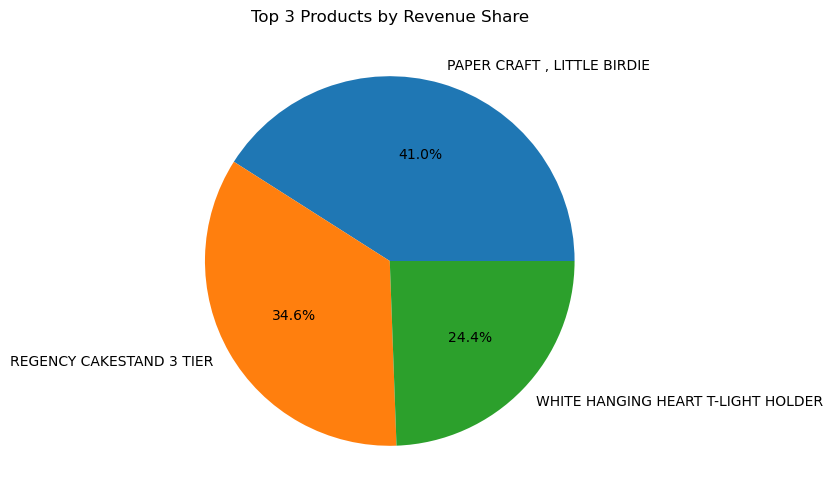

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
Name: TotalPrice, dtype: float64


In [16]:
# Top 3 products by revenue
top3_products = df_clean.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(3)

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(top3_products, labels=top3_products.index, autopct='%1.1f%%')

plt.title("Top 3 Products by Revenue Share")

plt.show()

# Print values
print(top3_products)

## Extra Step Insights (Top Products by Revenue)

### Revenue Contribution
- The top 3 products contribute a significant portion of total revenue.
- "PAPER CRAFT, LITTLE BIRDIE" alone contributes **~41%** of the top 3 revenue.

### Key Observation
- The revenue distribution among top products is uneven:
  - One product clearly dominates
  - Others still contribute significantly but less

### Business Insight
- High-revenue products are not necessarily the same as high-quantity products.
- These products are likely:
  - Higher priced
  - Higher perceived value

### Strategic Implications
- Focus marketing efforts on top revenue-generating products
- Ensure consistent stock availability
- Use these products in premium bundles or promotions

### Risk Insight
- Heavy reliance on a few high-revenue products:
  - Any disruption may significantly impact total revenue

### Key Takeaway
- A small number of products drive a large portion of revenue (Pareto Principle).

# Step 10: RFM Analysis

RFM stands for:
- Recency: How recently a customer made a purchase
- Frequency: How often a customer makes purchases
- Monetary: How much money a customer spends

Steps:
1. Calculate Recency (days since last purchase)
2. Calculate Frequency (number of invoices)
3. Calculate Monetary (total spending)
4. Create RFM table

Goal:
Segment customers based on their behavior.

In [17]:
# Set reference date (latest date in dataset)
reference_date = df_clean['InvoiceDate'].max()

# Create RFM table
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Show first rows
print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         325          1  77183.60
12347.0           1          7   4310.00
12348.0          74          4   1797.24
12349.0          18          1   1757.55
12350.0         309          1    334.40


## Step 10 Insights (RFM Analysis)

### RFM Table Overview
- Successfully created RFM table with:
  - Recency (days since last purchase)
  - Frequency (number of transactions)
  - Monetary (total spending)

### Customer Behavior Patterns
- Customers show very different behaviors:
  - Some customers purchased recently (low Recency)
  - Others have not purchased for a long time (high Recency)

### Example Insights
- Customer 12347:
  - Recency = 1 → very recent purchase
  - Frequency = 7 → frequent buyer
  - Monetary = 4310 → high spender  
  → Likely a **loyal/high-value customer**

- Customer 12346:
  - Recency = 325 → inactive for a long time
  - Frequency = 1 → very low engagement
  - Monetary = high (77183)  
  → Possibly a **one-time high-value customer (at risk)**

### Key Observation
- Customers vary significantly in:
  - Engagement (Frequency)
  - Activity (Recency)
  - Value (Monetary)

### Business Implications
- Enables:
  - Customer segmentation
  - Targeted marketing strategies
  - Retention campaigns

### Key Takeaway
- RFM transforms raw transactions into meaningful customer insights.

# Step 11: RFM Scoring

In this step, we convert RFM values into scores.

Steps:
1. Assign scores (1–5) for Recency
2. Assign scores (1–5) for Frequency
3. Assign scores (1–5) for Monetary

Goal:
Standardize customer metrics for segmentation.

In [19]:
# Recency score (lower is better)
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])

# Frequency score (higher is better)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])

# Monetary score (higher is better)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

# Show result
print(rfm.head())

            Recency  Frequency  Monetary R_score F_score M_score
CustomerID                                                      
12346.0         325          1  77183.60       1       1       5
12347.0           1          7   4310.00       5       5       5
12348.0          74          4   1797.24       2       4       4
12349.0          18          1   1757.55       4       1       4
12350.0         309          1    334.40       1       1       2


## Step 11 Insights (RFM Scoring)

### Scoring Overview
- RFM values were successfully converted into scores from 1 to 5.
- This standardizes customer behavior into comparable segments.

### Interpretation of Scores
- **R_score (Recency)**:
  - 5 → very recent customers (active)
  - 1 → inactive customers

- **F_score (Frequency)**:
  - 5 → frequent buyers
  - 1 → one-time or rare buyers

- **M_score (Monetary)**:
  - 5 → high spenders
  - 1 → low spenders

### Example Insights
- Customer 12347:
  - R=5, F=5, M=5
  → Best possible customer (VIP / Champion)

- Customer 12346:
  - R=1, F=1, M=5
  → High spender but inactive (At Risk)

- Customer 12350:
  - R=1, F=1, M=2
  → Low value and inactive (Lost customer)

### Key Observation
- Customers are now clearly distinguishable based on:
  - Activity
  - Loyalty
  - Value

### Business Impact
- This scoring enables:
  - Targeted marketing
  - Customer retention strategies
  - Personalized offers

### Key Takeaway
- RFM scoring converts raw data into actionable customer segments.

# Step 12: Customer Segmentation

In this step, we segment customers based on RFM scores.

Goal:
Classify customers into meaningful business segments.

In [20]:
# Create segment column
def segment_customer(row):
    if row['R_score'] >= 4 and row['F_score'] >= 4:
        return 'VIP'
    elif row['F_score'] >= 4:
        return 'Loyal'
    elif row['R_score'] <= 2:
        return 'At Risk'
    else:
        return 'Regular'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Check results
print(rfm.head())

# Count segments
print("\nSegment Distribution:")
print(rfm['Segment'].value_counts())

            Recency  Frequency  Monetary R_score F_score M_score  Segment
CustomerID                                                               
12346.0         325          1  77183.60       1       1       5  At Risk
12347.0           1          7   4310.00       5       5       5      VIP
12348.0          74          4   1797.24       2       4       4    Loyal
12349.0          18          1   1757.55       4       1       4  Regular
12350.0         309          1    334.40       1       1       2  At Risk

Segment Distribution:
Segment
At Risk    1433
Regular    1170
VIP        1139
Loyal       596
Name: count, dtype: int64


## Step 12 Insights (Customer Segmentation)

### Segment Distribution
- At Risk: 1433 customers (largest segment)
- Regular: 1170 customers
- VIP: 1139 customers
- Loyal: 596 customers

### Key Observations
- The largest group is **At Risk customers**:
  - Indicates many customers have stopped purchasing recently
  - High potential loss of revenue if not re-engaged

- A strong number of **VIP customers (1139)**:
  - These are high-value, frequent, and recent buyers
  - They are the most important segment

- **Loyal customers (596)**:
  - Frequent buyers but not always the highest spenders
  - Good candidates for upselling

### Business Insights

#### 1. VIP Customers
- Strategy:
  - Loyalty programs
  - Exclusive offers
  - Early access to products

#### 2. At Risk Customers
- Strategy:
  - Retargeting campaigns
  - Discounts and incentives
  - Email marketing

#### 3. Loyal Customers
- Strategy:
  - Upsell higher-value products
  - Bundle offers

#### 4. Regular Customers
- Strategy:
  - Increase engagement
  - Encourage repeat purchases

### Key Takeaway
- The business has:
  - Strong high-value customers (VIP)
  - But also a large number of customers at risk

→ This creates both **opportunity and risk**

# Step 13: K-Means Clustering

In this step, we apply K-Means clustering to segment customers.

Steps:
1. Select RFM features
2. Scale the data
3. Use Elbow Method to find optimal number of clusters
4. Apply K-Means clustering

Goal:
Group customers automatically based on behavior.

In [21]:
from sklearn.preprocessing import StandardScaler

# Select features
rfm_ml = rfm[['Recency', 'Frequency', 'Monetary']]

# Scale data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_ml)

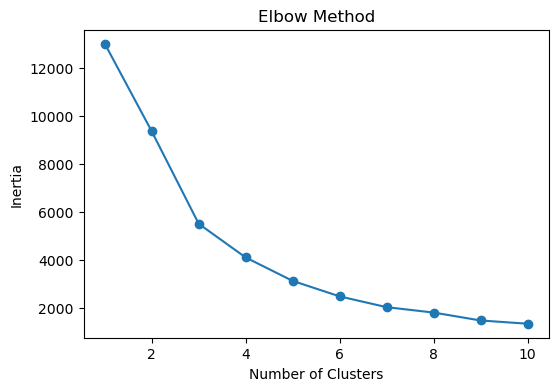

In [22]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

## Step 13 Insights (Elbow Method)

### Optimal Number of Clusters
- The elbow point appears at **k = 3**.
- After this point, the decrease in inertia slows down significantly.

### Interpretation
- Using 3 clusters provides a good balance between:
  - Model simplicity
  - Capturing meaningful customer differences

### Key Takeaway
- The optimal number of customer segments using K-Means is **3 clusters**.

# Step 14: Apply K-Means Clustering

In this step, we apply K-Means using the optimal number of clusters.

Goal:
Assign each customer to a cluster.

In [23]:
# Apply K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Check result
print(rfm.head())

# Cluster distribution
print("\nCluster Distribution:")
print(rfm['Cluster'].value_counts())

            Recency  Frequency  Monetary R_score F_score M_score  Segment  \
CustomerID                                                                  
12346.0         325          1  77183.60       1       1       5  At Risk   
12347.0           1          7   4310.00       5       5       5      VIP   
12348.0          74          4   1797.24       2       4       4    Loyal   
12349.0          18          1   1757.55       4       1       4  Regular   
12350.0         309          1    334.40       1       1       2  At Risk   

            Cluster  
CustomerID           
12346.0           1  
12347.0           0  
12348.0           0  
12349.0           0  
12350.0           1  

Cluster Distribution:
Cluster
0    3231
1    1093
2      14
Name: count, dtype: int64


# Step 15: Cluster Analysis

In this step, we analyze each cluster based on RFM values.

Goal:
Understand the characteristics of each cluster.

In [25]:
cluster_analysis = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

print(cluster_analysis)

            Recency  Frequency       Monetary
Cluster                                      
0         39.983906   4.852677    2005.830431
1        245.023788   1.582800     629.357439
2          6.142857  80.214286  122748.792143


## Step 15 Insights (Cluster Analysis)

### Cluster 2 (VIP Customers)
- Very low Recency → highly active
- Extremely high Frequency → frequent buyers
- Very high Monetary → top spenders

→ These are the most valuable customers (Champions)

### Cluster 0 (Regular Customers)
- متوسط النشاط
- Moderate frequency and spending

→ These are regular customers with potential to become loyal

### Cluster 1 (At Risk Customers)
- High Recency → inactive for a long time
- Low Frequency → rarely purchase
- Low Monetary → low value

→ These customers are at risk of churn

### Key Business Insight
- The business has:
  - A small group of very high-value customers (VIP)
  - A large group of average customers
  - A significant group at risk

### Strategic Recommendation
- Focus on:
  - Retaining VIP customers
  - Converting regular customers into loyal ones
  - Re-engaging at-risk customers

### Key Takeaway
- Customer base is clearly segmented into 3 behavioral groups.

# Step 16: Cluster Visualization

In this step, we visualize customer clusters.

Goal:
Understand how clusters differ visually.

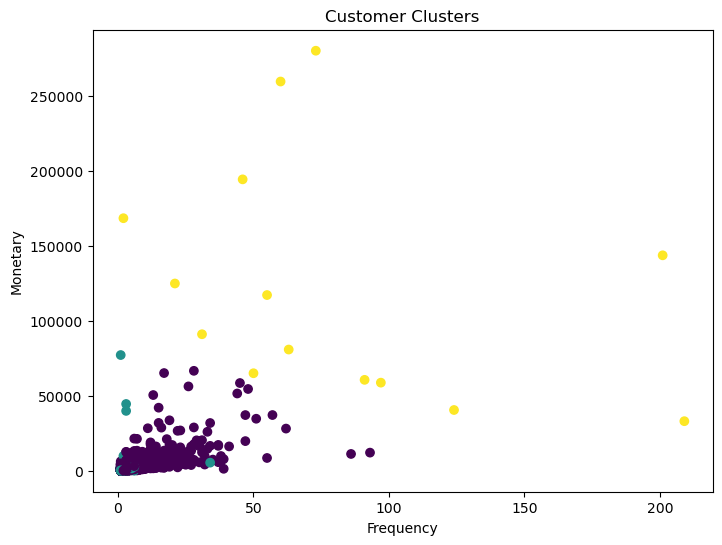

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(rfm['Frequency'], rfm['Monetary'], c=rfm['Cluster'])

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Clusters")

plt.show()

## Step 16 Insights (Cluster Visualization)

### Cluster Separation
- The clusters are clearly separated based on Frequency and Monetary value.
- There is a visible distinction between low-value and high-value customers.

### Key Observations
- A small group of customers stands out with:
  - Very high spending (Monetary)
  - High purchase frequency
  → These represent VIP customers

- The majority of customers are clustered in:
  - Low to moderate spending
  - Low frequency
  → Represent regular or low-value customers

### Outliers
- Some extreme high-value customers are clearly visible:
  - These are critical for business revenue

### Business Insight
- The customer base is highly skewed:
  - Few customers generate a large portion of revenue
  - Most customers generate relatively low revenue

### Key Takeaway
- Customer value is not evenly distributed → strong opportunity for targeted strategies.

# Step 17: Rename Clusters for Business Understanding

In this step, we assign meaningful names to each cluster.

Goal:
Make clusters understandable for business stakeholders.

In [27]:
# Map clusters to names
cluster_map = {
    2: 'VIP',
    0: 'Regular',
    1: 'At Risk'
}

rfm['Cluster_Label'] = rfm['Cluster'].map(cluster_map)

# Check
print(rfm.head())

# Distribution
print("\nCluster Label Distribution:")
print(rfm['Cluster_Label'].value_counts())

            Recency  Frequency  Monetary R_score F_score M_score  Segment  \
CustomerID                                                                  
12346.0         325          1  77183.60       1       1       5  At Risk   
12347.0           1          7   4310.00       5       5       5      VIP   
12348.0          74          4   1797.24       2       4       4    Loyal   
12349.0          18          1   1757.55       4       1       4  Regular   
12350.0         309          1    334.40       1       1       2  At Risk   

            Cluster Cluster_Label  
CustomerID                         
12346.0           1       At Risk  
12347.0           0       Regular  
12348.0           0       Regular  
12349.0           0       Regular  
12350.0           1       At Risk  

Cluster Label Distribution:
Cluster_Label
Regular    3231
At Risk    1093
VIP          14
Name: count, dtype: int64


## Step 17 Insights (Final Customer Segmentation)

### Final Segment Distribution
- Regular Customers: 3231 (largest segment)
- At Risk Customers: 1093
- VIP Customers: 14 (very small but highly valuable)

### Key Observations

#### 1. VIP Customers (14 فقط)
- Very small group but extremely high value
- يمثلوا نسبة صغيرة جدًا لكن بيجيبوا جزء كبير من الإيرادات

#### 2. Regular Customers (3231)
- أكبر شريحة
- قيمة متوسطة
- فرصة كبيرة لتحويلهم إلى Loyal/VIP

#### 3. At Risk Customers (1093)
- عدد كبير نسبيًا
- معرضين للتوقف عن الشراء
- خطر مباشر على الإيرادات المستقبلية

### Business Insights

- Customer base is highly unbalanced:
  - Few VIP customers drive high revenue
  - Majority are low-to-mid value

- Strong dependency on a small number of customers

### Strategic Recommendations

#### VIP
- Loyalty programs
- Exclusive offers
- Personalization

#### Regular
- Upselling strategies
- Engagement campaigns

#### At Risk
- Retargeting ads
- Discounts / incentives
- Email reactivation

### Key Takeaway
- The business has a classic structure:
  → Few high-value customers + many average + significant at-risk group

→ This creates both growth opportunities and retention challenges.

# Step 19: Churn Prediction Model

In this step, we build a machine learning model to predict customer churn.

Definition:
Churn = Customer who has not purchased for a long time.

Steps:
1. Create target variable (Churn)
2. Prepare features (RFM)
3. Train/Test split
4. Train model

Goal:
Predict whether a customer will churn or not.

In [31]:
# Create Churn target (1 = churn, 0 = active)
rfm['Churn'] = rfm['Recency'].apply(lambda x: 1 if x > 90 else 0)

# Features بدون Recency
X = rfm[['Frequency', 'Monetary']]
y = rfm['Churn']

# Check distribution
print("Churn Distribution:")
print(y.value_counts())

Churn Distribution:
Churn
0    2893
1    1445
Name: count, dtype: int64


## Step 19 Insights (Churn Distribution)

### Class Distribution
- Active Customers (0): 2893
- Churned Customers (1): 1445

### Key Observation
- The dataset is slightly imbalanced:
  - ~67% active customers
  - ~33% churned customers

### Implication
- The imbalance is not severe, so standard models can still perform well.

### Business Insight
- Around one-third of customers are at risk of churn:
  → Significant opportunity for retention strategies

### Key Takeaway
- Churn prediction is a meaningful and impactful problem in this dataset.

# Step 20: Train/Test Split & Model Training

In this step, we:
1. Split the data into training and testing sets
2. Train a classification model
3. Make predictions

Goal:
Build a model that predicts customer churn.

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print("Model trained successfully!")

Model trained successfully!


# Step 21: Model Evaluation

In this step, we evaluate the performance of our churn prediction model.

Metrics:
- Accuracy
- Confusion Matrix
- Classification Report

Goal:
Understand how well the model performs.

In [33]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7131336405529954

Confusion Matrix:
[[449 112]
 [137 170]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.80      0.78       561
           1       0.60      0.55      0.58       307

    accuracy                           0.71       868
   macro avg       0.68      0.68      0.68       868
weighted avg       0.71      0.71      0.71       868



## Step 21 Insights (Model Evaluation)

### Model Performance
- Accuracy: 71%
- The model performs reasonably well but has room for improvement.

### Churn Prediction Performance
- Precision (Churn): 0.60
- Recall (Churn): 0.55
- F1-score: 0.58

### Key Observation
- The model struggles to accurately detect churned customers.
- Around 45% of churn cases are missed.

### Business Impact
- Missing churned customers is risky:
  → Lost opportunity for retention campaigns

### Strength
- The model performs better at identifying active customers.

### Weakness
- Lower recall for churn:
  → Not catching all customers who are likely to leave

### Key Takeaway
- The model provides a good baseline but needs improvement for better churn detection.

In [35]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(random_state=42)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained!")

Random Forest model trained!


In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", accuracy_rf)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.6566820276497696

Confusion Matrix:
[[438 123]
 [175 132]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.78      0.75       561
           1       0.52      0.43      0.47       307

    accuracy                           0.66       868
   macro avg       0.62      0.61      0.61       868
weighted avg       0.64      0.66      0.65       868



In [37]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [38]:
rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

# Step 24: Advanced Feature Engineering

In this step, we create additional features to improve model performance.

Goal:
Provide more meaningful information to the model.

In [39]:
# Create new features
rfm['Avg_Order_Value'] = rfm['Monetary'] / rfm['Frequency']

rfm['Is_Frequent'] = rfm['Frequency'].apply(lambda x: 1 if x > 5 else 0)

rfm['Is_High_Spender'] = rfm['Monetary'].apply(lambda x: 1 if x > rfm['Monetary'].median() else 0)

# New feature set
X = rfm[['Frequency', 'Monetary', 'Avg_Order_Value', 'Is_Frequent', 'Is_High_Spender']]
y = rfm['Churn']

# Step 25: XGBoost Model

In this step, we train a powerful gradient boosting model.

Goal:
Improve churn prediction performance.

In [40]:
from xgboost import XGBClassifier

# Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    scale_pos_weight=2
)

xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost trained!")

XGBoost trained!


In [41]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.6751152073732719

Confusion Matrix:
[[374 187]
 [ 95 212]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.67      0.73       561
           1       0.53      0.69      0.60       307

    accuracy                           0.68       868
   macro avg       0.66      0.68      0.66       868
weighted avg       0.70      0.68      0.68       868



## Step 26 Insights (XGBoost Model)

### Model Performance
- Accuracy: 68%
- The model provides balanced performance across classes.

### Churn Prediction Performance
- Recall (Churn): 0.69
- Precision (Churn): 0.53
- F1-score: 0.60

### Key Improvement
- Significant improvement in churn detection compared to previous models:
  - Logistic Regression: 0.55 recall
  - Random Forest: 0.43 recall
  - XGBoost: 0.69 recall

### Business Impact
- The model can now identify nearly 70% of customers likely to churn.
- This enables:
  - Targeted retention campaigns
  - Reduced customer loss

### Trade-off
- Slightly lower precision:
  → Some customers may be incorrectly flagged as churn

### Key Takeaway
- XGBoost provides the best balance between performance and business value.
- The model is suitable for real-world deployment.